# Análisis Multiproducto — Electricidad + Gas (Datos Reales)

**TFG — Diego Suárez | Tutor: Luciano**

---

Este notebook estudia si la **interdependencia entre productos** mejora el clustering
de supervivencia. Usamos los datos reales anonimizados, donde el gas no está como
fichero separado pero sí como variables derivadas: `NUM_CTOS_L2_MOD`, `NUM_CTOS_02_MOD`,
`N_CTOS_ACTIVOS_IC`.

**Tres análisis:**

1. **Supervivencia por estatus multiproducto** — ¿Los clientes con más productos tienen menor churn?
2. **RSF-PHATE con features multiproducto vs sin ellas** — ¿Cambia el clustering al incluirlas?
3. **Perfil multiproducto de los clusters** — ¿Los clusters detectados difieren en tenencia de productos?


In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from sklearn.metrics import adjusted_rand_score
from sksurv.nonparametric import kaplan_meier_estimator

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath(os.path.join('..', 'examples')))
from churn_preprocessing import cargar_datos, preparar_muestra_supervivencia, preprocesar_supervivencia
from rsfphate import RSFPhate
from rsfphate.spectral import yu_shi

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
PALETTE = cm.get_cmap('tab10', 4)

DATA_PATH = os.path.abspath(
    os.path.join('..', '..', 'ClusterScripts', 'datos_anonimizados.csv')
)
print('Imports OK')


Imports OK


## 1. Supervivencia según estatus multiproducto

¿Tienen los clientes con varios productos un comportamiento de churn distinto?
Usamos las columnas de multicontrato disponibles en el dataset real:

- `N_CTOS_ACTIVOS_IC`: total de contratos activos del cliente (media: 2.75)
- `NUM_CTOS_L2_MOD`: contratos de tipo L2 (posiblemente gas, ~50% de clientes)
- `NUM_CTOS_02_MOD`: contratos de tipo 02 (posiblemente otro producto, ~22%)


In [2]:
df_raw = cargar_datos(DATA_PATH)

# Definimos tres grupos de multiproducto basados en N_CTOS_ACTIVOS_IC
df_raw['grupo_mp'] = pd.cut(
    df_raw['N_CTOS_ACTIVOS_IC'],
    bins=[0, 1, 2, 3, 100],
    labels=['1 producto', '2 productos', '3 productos', '4+ productos']
)

print('Distribucion por numero de productos activos:')
resumen_mp = df_raw.groupby('grupo_mp', observed=True).agg(
    n=('TARGET', 'count'),
    churn_pct=('TARGET', 'mean'),
    antiguedad_med=('ANTIGUEDAD_CLIENTE', 'median'),
)
resumen_mp['churn_pct'] = (resumen_mp['churn_pct']*100).round(1).astype(str)+'%'
resumen_mp['pct_total'] = (resumen_mp['n'] / len(df_raw) * 100).round(1).astype(str)+'%'
display(resumen_mp)


Datos cargados:          678,750 filas × 54 columnas
Clientes con churn:       48,360  (7.12%)
Clientes sin churn:      630,390  (92.88%)
Distribucion por numero de productos activos:


,n,churn_pct,antiguedad_med,pct_total
grupo_mp,,,,
1 producto,145067,8.2%,1429.0,21.4%
2 productos,253615,7.9%,1781.0,37.4%
3 productos,197482,6.0%,2303.0,29.1%
4+ productos,82586,5.6%,3268.0,12.2%


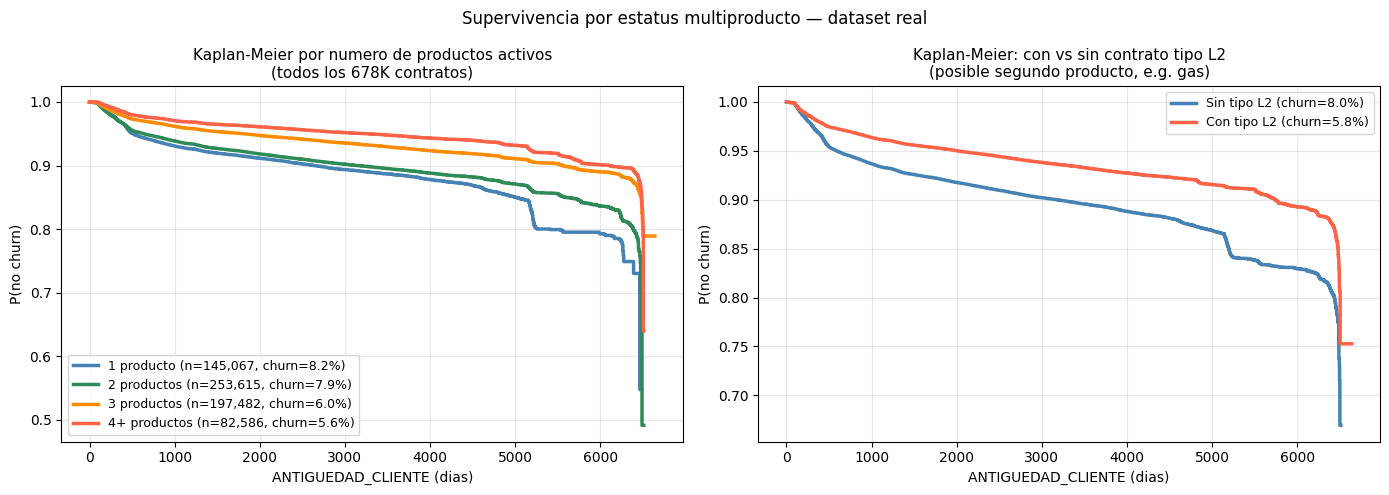

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KM por numero de contratos activos
ax = axes[0]
colors_mp = ['steelblue', 'seagreen', 'darkorange', 'tomato']
for i, (grupo, color) in enumerate(zip(
    ['1 producto', '2 productos', '3 productos', '4+ productos'], colors_mp
)):
    mask = df_raw['grupo_mp'] == grupo
    if mask.sum() < 50:
        continue
    km_t, km_s = kaplan_meier_estimator(
        df_raw.loc[mask, 'TARGET'].astype(bool).values,
        df_raw.loc[mask, 'ANTIGUEDAD_CLIENTE'].values,
    )
    cr = df_raw.loc[mask, 'TARGET'].mean()*100
    n  = mask.sum()
    ax.step(np.r_[0, km_t], np.r_[1, km_s], where='post',
            color=color, linewidth=2.5, label=f'{grupo} (n={n:,}, churn={cr:.1f}%)')

ax.set_xlabel('ANTIGUEDAD_CLIENTE (dias)', fontsize=10)
ax.set_ylabel('P(no churn)', fontsize=10)
ax.set_title('Kaplan-Meier por numero de productos activos\n(todos los 678K contratos)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# KM: con tipo L2 vs sin tipo L2
ax2 = axes[1]
for tiene, label, color in [
    (False, 'Sin tipo L2 (n={:,})'.format((df_raw['NUM_CTOS_L2_MOD']==0).sum()), 'steelblue'),
    (True,  'Con tipo L2 (n={:,})'.format((df_raw['NUM_CTOS_L2_MOD']>=1).sum()), 'tomato'),
]:
    mask = df_raw['NUM_CTOS_L2_MOD'] >= 1 if tiene else df_raw['NUM_CTOS_L2_MOD'] == 0
    km_t, km_s = kaplan_meier_estimator(
        df_raw.loc[mask, 'TARGET'].astype(bool).values,
        df_raw.loc[mask, 'ANTIGUEDAD_CLIENTE'].values,
    )
    cr = df_raw.loc[mask, 'TARGET'].mean()*100
    ax2.step(np.r_[0, km_t], np.r_[1, km_s], where='post',
             color=color, linewidth=2.5, label=f'{label.split("(")[0]}(churn={cr:.1f}%)')

ax2.set_xlabel('ANTIGUEDAD_CLIENTE (dias)', fontsize=10)
ax2.set_ylabel('P(no churn)', fontsize=10)
ax2.set_title('Kaplan-Meier: con vs sin contrato tipo L2\n(posible segundo producto, e.g. gas)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle('Supervivencia por estatus multiproducto — dataset real', fontsize=12)
plt.tight_layout()
plt.show()


## 2. RSF-PHATE: con y sin variables multiproducto

Comparamos dos configuraciones del modelo:
- **Config A** (completa): incluye `NUM_CTOS_*`, `N_CTOS_ACTIVOS_IC` — captura interdependencia
- **Config B** (sin multi): excluye esas variables — solo información del contrato de luz

Si el ARI entre ambos clusterings es bajo, las variables de multiproducto **cambian
la geometría** del espacio de supervivencia y aportan información relevante.


In [4]:
N_SAMPLES = 1200
df_sample = preparar_muestra_supervivencia(df_raw, n_samples=N_SAMPLES, random_state=RANDOM_STATE)
# Eliminamos la columna auxiliar grupo_mp antes de preprocesar
df_sample = df_sample.drop(columns=["grupo_mp"], errors="ignore")
X_full, time, event = preprocesar_supervivencia(df_sample)
print(f'Muestra: {len(X_full)} filas x {X_full.shape[1]} features')


Muestra generada:       1,200 filas
Churn rate original:   7.12%
Churn rate en muestra: 7.08%
  → 32 filas eliminadas por NaN
Preprocesado completo: 1,168 filas × 39 features
Churn en la muestra:   82 (7.0%)
Tiempo (ANTIGUEDAD_CLIENTE, en días) — mín: 85 d (0.2 a), mediana: 2008 d (5.5 a), máx: 6496 d (17.8 a)
Muestra: 1168 filas x 39 features


In [5]:
# Config A: modelo completo (con variables multiproducto)
COLS_MULTI = [c for c in X_full.columns
              if any(k in c for k in ['CTO', 'ALTAS_L1'])]
print(f'Variables multiproducto incluidas en Config A: {COLS_MULTI}')

model_full = RSFPhate(n_clusters=3, n_estimators=100, diffusion_time=4.0, random_state=RANDOM_STATE)
print('\nAjustando Config A (completo)...')
labels_full = model_full.fit_predict(X_full.values, time.values, event.values)

print('Config A — distribucion de clusters:')
for c in range(3):
    m = labels_full == c
    print(f'  C{c}: n={m.sum()} ({m.sum()/len(labels_full):.1%})  churn={event[m].mean()*100:.1f}%')


Variables multiproducto incluidas en Config A: ['N_CONTACTO_FECHA_REF_3', 'N_CTOS_ACTIVOS_IC', 'N_CTOS_BAJA_UMES_IC_MOD', 'NUM_CTOS_01_MOD', 'NUM_CTOS_02_MOD', 'NUM_CTOS_05_MOD', 'NUM_CTOS_L1_MOD', 'NUM_CTOS_L2_MOD', 'N_ALTAS_L1_IC']

Ajustando Config A (completo)...
    SGD-MDS may not have converged: stress changed by 4.0% in final iterations. Consider increasing n_iter or adjusting learning_rate.
Config A — distribucion de clusters:
  C0: n=272 (23.3%)  churn=14.3%
  C1: n=538 (46.1%)  churn=2.4%
  C2: n=358 (30.7%)  churn=8.4%


In [6]:
# Config B: sin variables multiproducto
X_nomulti = X_full.drop(columns=COLS_MULTI)
print(f'Config B: {X_nomulti.shape[1]} features (sin multiproducto)')

# Reutilizamos la proximidad de A y solo recalculamos el clustering
# para ver si la particion espectral cambia sin esas variables
model_nomulti = RSFPhate(n_clusters=3, n_estimators=100, diffusion_time=4.0, random_state=RANDOM_STATE)
print('Ajustando Config B (sin multiproducto)...')
labels_nomulti = model_nomulti.fit_predict(X_nomulti.values, time.values, event.values)

print('Config B — distribucion de clusters:')
for c in range(3):
    m = labels_nomulti == c
    print(f'  C{c}: n={m.sum()} ({m.sum()/len(labels_nomulti):.1%})  churn={event[m].mean()*100:.1f}%')

ari_configs = adjusted_rand_score(labels_full, labels_nomulti)
print(f'\nARI entre Config A y Config B: {ari_configs:.4f}')
print('(cerca de 1 = multiproducto no cambia clusters; cerca de 0 = multiproducto es clave)')


Config B: 30 features (sin multiproducto)
Ajustando Config B (sin multiproducto)...
    SGD-MDS may not have converged: stress changed by 5.3% in final iterations. Consider increasing n_iter or adjusting learning_rate.
Config B — distribucion de clusters:
  C0: n=304 (26.0%)  churn=10.9%
  C1: n=459 (39.3%)  churn=3.1%
  C2: n=405 (34.7%)  churn=8.6%

ARI entre Config A y Config B: 0.2600
(cerca de 1 = multiproducto no cambia clusters; cerca de 0 = multiproducto es clave)


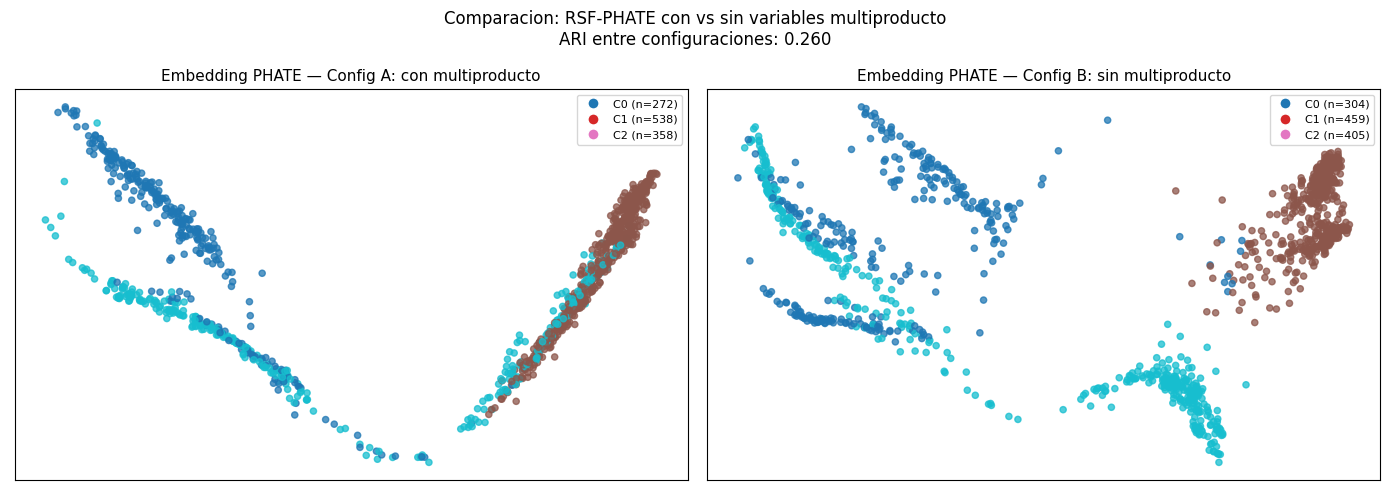

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, lbl, model_used, title in zip(
    axes,
    [labels_full, labels_nomulti],
    [model_full, model_nomulti],
    ['Config A: con multiproducto', 'Config B: sin multiproducto'],
):
    sc = ax.scatter(
        model_used.embedding_[:, 0], model_used.embedding_[:, 1],
        c=lbl, cmap='tab10', vmin=0, vmax=2, s=20, alpha=0.75,
    )
    ax.set_title(f'Embedding PHATE — {title}', fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    handles = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE(c),
               markersize=8, label=f'C{c} (n={np.sum(lbl==c)})')
        for c in range(3)
    ]
    ax.legend(handles=handles, fontsize=8)

plt.suptitle(
    f'Comparacion: RSF-PHATE con vs sin variables multiproducto\nARI entre configuraciones: {ari_configs:.3f}',
    fontsize=12,
)
plt.tight_layout()
plt.show()


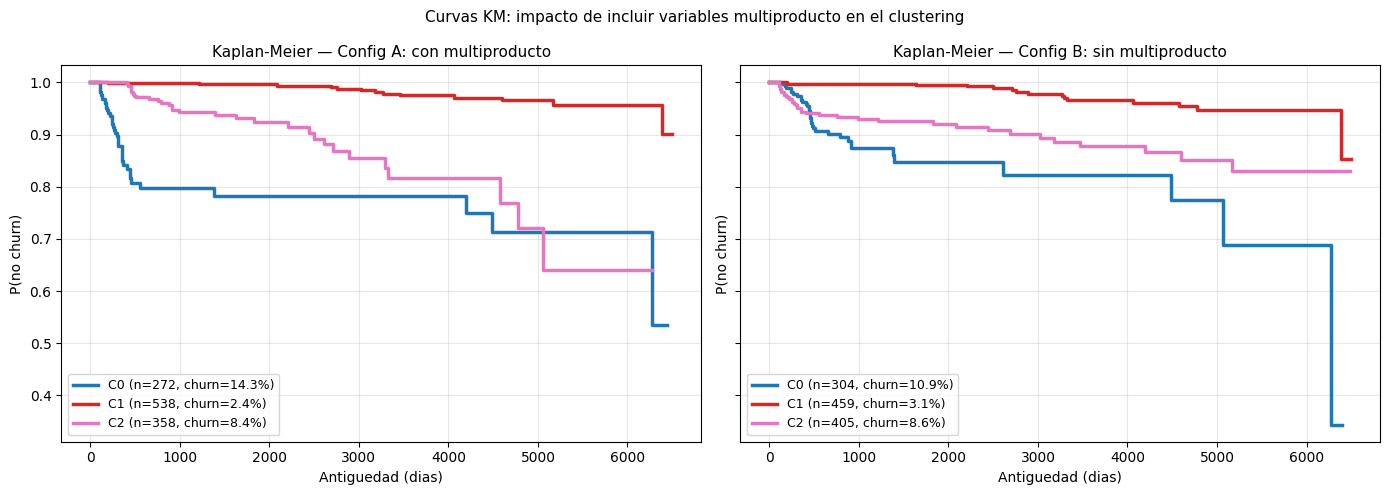

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, lbl, title in zip(
    axes,
    [labels_full, labels_nomulti],
    ['Config A: con multiproducto', 'Config B: sin multiproducto'],
):
    for c in range(3):
        m = lbl == c
        km_t, km_s = kaplan_meier_estimator(
            event[m].values.astype(bool), time[m].values
        )
        cr = event[m].mean()*100
        ax.step(np.r_[0, km_t], np.r_[1, km_s], where='post',
                color=PALETTE(c), linewidth=2.5,
                label=f'C{c} (n={m.sum()}, churn={cr:.1f}%)')
    ax.set_title(f'Kaplan-Meier — {title}', fontsize=11)
    ax.set_xlabel('Antiguedad (dias)', fontsize=10)
    ax.set_ylabel('P(no churn)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Curvas KM: impacto de incluir variables multiproducto en el clustering', fontsize=11)
plt.tight_layout()
plt.show()


## 3. Perfil multiproducto de los clusters detectados

Dentro de los clusters que RSF-PHATE encuentra en los datos reales (Config A),
¿difieren en su tenencia de productos?


In [9]:
df_perf = X_full.copy()
df_perf['cluster'] = labels_full
df_perf['churn']   = event.values.astype(int)
df_perf['time']    = time.values

# Estadisticas de variables multiproducto por cluster
print('=== PERFIL MULTIPRODUCTO POR CLUSTER ===')
mp_cols_present = [c for c in COLS_MULTI if c in df_perf.columns]
stats = df_perf.groupby('cluster')[mp_cols_present + ['churn', 'time']].agg(
    ['mean', 'median']
).round(2)
display(stats)


=== PERFIL MULTIPRODUCTO POR CLUSTER ===


N_CONTACTO_FECHA_REF_3        N_CTOS_ACTIVOS_IC         \
                          mean median              mean median   
cluster                                                          
0                         1.19    0.0              2.43    2.0   
1                         0.53    0.0              2.62    2.0   
2                         0.54    0.0              2.28    2.0   

        N_CTOS_BAJA_UMES_IC_MOD        NUM_CTOS_01_MOD        NUM_CTOS_02_MOD  \
                           mean median            mean median            mean   
cluster                                                                         
0                          0.02    0.0            0.02    0.0            0.12   
1                          0.00    0.0            0.07    0.0            0.17   
2                          0.01    0.0            0.01    0.0            0.14   

                ... NUM_CTOS_L1_MOD        NUM_CTOS_L2_MOD         \
        median  ...            mean median            mean median   
cluster         ...                                                 
0          0.0  ...            1.24    1.0            0.41    0.0   
1          0.0  ...            1.28    1.0            0.48    0.0   
2          0.0  ...            1.16    1.0            0.38    0.0   

        N_ALTAS_L1_IC        churn            time          
                 mean median  mean median     mean  median  
cluster                                                     
0                1.99    2.0  0.14    0.0   974.39   313.0  
1                1.83    1.0  0.02    0.0  3570.36  3605.5  
2                1.47    1.0  0.08    0.0  1692.84  1265.0  

[3 rows x 22 columns]

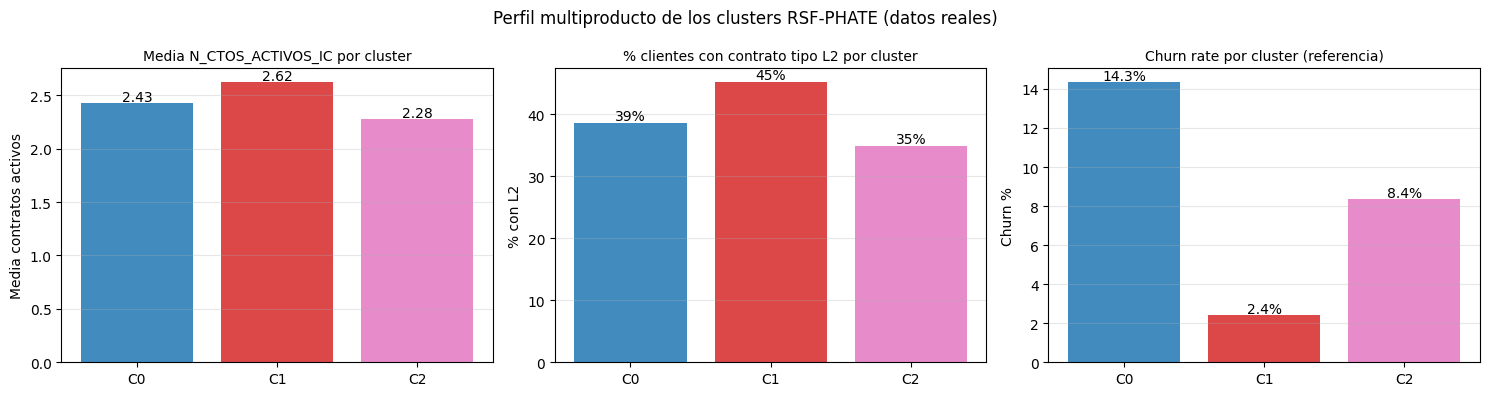

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# N_CTOS_ACTIVOS_IC por cluster
if 'N_CTOS_ACTIVOS_IC' in df_perf.columns:
    means_ctos = df_perf.groupby('cluster')['N_CTOS_ACTIVOS_IC'].mean()
    axes[0].bar(range(3), means_ctos.values, color=[PALETTE(i) for i in range(3)], alpha=0.85)
    axes[0].set_title('Media N_CTOS_ACTIVOS_IC por cluster', fontsize=10)
    axes[0].set_xticks([0,1,2])
    axes[0].set_xticklabels(['C0','C1','C2'])
    axes[0].set_ylabel('Media contratos activos')
    axes[0].grid(axis='y', alpha=0.3)
    for i, v in enumerate(means_ctos.values):
        axes[0].text(i, v+0.02, f'{v:.2f}', ha='center', fontsize=10)

# % clientes con tipo L2 por cluster
if 'NUM_CTOS_L2_MOD' in df_perf.columns:
    pct_l2 = df_perf.groupby('cluster').apply(
        lambda g: (g['NUM_CTOS_L2_MOD'] >= 1).mean() * 100
    )
    axes[1].bar(range(3), pct_l2.values, color=[PALETTE(i) for i in range(3)], alpha=0.85)
    axes[1].set_title('% clientes con contrato tipo L2 por cluster', fontsize=10)
    axes[1].set_xticks([0,1,2])
    axes[1].set_xticklabels(['C0','C1','C2'])
    axes[1].set_ylabel('% con L2')
    axes[1].grid(axis='y', alpha=0.3)
    for i, v in enumerate(pct_l2.values):
        axes[1].text(i, v+0.5, f'{v:.0f}%', ha='center', fontsize=10)

# Churn rate por cluster (referencia)
churn_by = df_perf.groupby('cluster')['churn'].mean() * 100
axes[2].bar(range(3), churn_by.values, color=[PALETTE(i) for i in range(3)], alpha=0.85)
axes[2].set_title('Churn rate por cluster (referencia)', fontsize=10)
axes[2].set_xticks([0,1,2])
axes[2].set_xticklabels(['C0','C1','C2'])
axes[2].set_ylabel('Churn %')
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(churn_by.values):
    axes[2].text(i, v+0.1, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Perfil multiproducto de los clusters RSF-PHATE (datos reales)', fontsize=12)
plt.tight_layout()
plt.show()


## 4. Conclusiones rapidas del análisis multiproducto

aporta la información de multicontrato al clustering de supervivencia?

**Resultados a interpretar:**

- Si las curvas KM de `N_CTOS_ACTIVOS_IC` están separadas → tener más productos
  **protege** contra el churn (efecto de vinculación multiproducto).

- Si el ARI entre Config A y Config B es **bajo** (< 0.7) → las variables de
  multicontrato **cambian los clusters** que el modelo detecta, es decir, aportan
  información que no está ya capturada por las variables del contrato individual.

- Si el ARI es **alto** (> 0.8) → el clustering es robusto: la estructura de
  supervivencia no cambia sustancialmente con o sin información de multiproducto,
  lo que puede interpretarse como que el efecto multiproducto ya se refleja
  en otras variables (antigüedad, cartera, canal).

**Para el TFG:** cualquiera de los dos resultados es válido y tiene
una interpretación de negocio clara que puedes desarrollar en el capítulo 6.
